In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- USER INPUT --------
emory_file = "/hpc/home/yy450/link_kamaleswaranlab/EmoryDataset/EMR_RAW/2022/CJSEPSIS_ENCOUNTER_2022.dsv"
mimic_file = "/hpc/home/yy450/link_kamaleswaranlab/mimic_iv/builtdata/csv_concepts_exports/icustay_detail.csv"

# Load CSVs
df_emory = pd.read_csv(emory_file, sep='|') 
# df_emory = pd.read_csv(emory_file) 
df_mimic = pd.read_csv(mimic_file)
# ----------------------------

print(f"✅ Loaded Emory: {df_emory.shape}, MIMIC: {df_mimic.shape}")
print(f"📋 Emory Columns: {list(df_emory.columns)}")
print(f"📋 MIMIC Columns: {list(df_mimic.columns)}")

✅ Loaded Emory: (175186, 18), MIMIC: (94458, 18)
📋 Emory Columns: ['pat_id', 'csn', 'age', 'ed_arrival_source', 'pre_admit_location', 'ed_presentation_time', 'hospital_admission_date_time', 'hospital_discharge_date_time', 'admit_reason', 'insurance_status', 'cpr_in_ed', 'total_icu_days', 'total_vent_days', 'total_hosp_days', 'discharge_status', 'discharge_to', 'encounter_type', 'facility_nm']
📋 MIMIC Columns: ['subject_id', 'hadm_id', 'stay_id', 'gender', 'dod', 'admittime', 'dischtime', 'los_hospital', 'admission_age', 'race', 'hospital_expire_flag', 'hospstay_seq', 'first_hosp_stay', 'icu_intime', 'icu_outtime', 'los_icu', 'icustay_seq', 'first_icu_stay']


In [18]:

emory_col = "total_icu_days"
mimic_col = "los_icu"

# Check if specified columns exist
if emory_col not in df_emory.columns:
    raise ValueError(f"'{emory_col}' not found in Emory file.")
if mimic_col not in df_mimic.columns:
    raise ValueError(f"'{mimic_col}' not found in MIMIC file.")

# Extract columns
# Extract target columns
# 强制转换
e_col = pd.to_numeric(df_emory[emory_col], errors='coerce')

# 找出非数字的原始值
invalid_values = df_emory.loc[e_col.isna(), emory_col].unique()
print(f"🚨 None numeric type examples ({len(invalid_values)}):\n", invalid_values[:20])

m_col = df_mimic[mimic_col]

🚨 None numeric type examples (1):
 [nan]


In [19]:

# -- 1. Null Count --
print("\nNull Counts:")
print(f"Emory - {emory_col}: {e_col.isnull().sum()} nulls out of {len(e_col)}")
print(f"MIMIC - {mimic_col}: {m_col.isnull().sum()} nulls out of {len(m_col)}")


Null Counts:
Emory - total_icu_days: 163768 nulls out of 175186
MIMIC - los_icu: 14 nulls out of 94458


In [20]:

# -- 2. Summary Stats --
print("\n📊 Summary Statistics:")
print("\nEmory:")
display(e_col.describe(include='all'))
print("\nMIMIC:")
display(m_col.describe(include='all'))


📊 Summary Statistics:

Emory:


count    11418.000000
mean         5.437029
std          8.164826
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max        153.000000
Name: total_icu_days, dtype: float64


MIMIC:


count    94444.000000
mean         3.630029
std          5.402484
min          0.000000
25%          1.100000
50%          1.970000
75%          3.860000
max        226.400000
Name: los_icu, dtype: float64

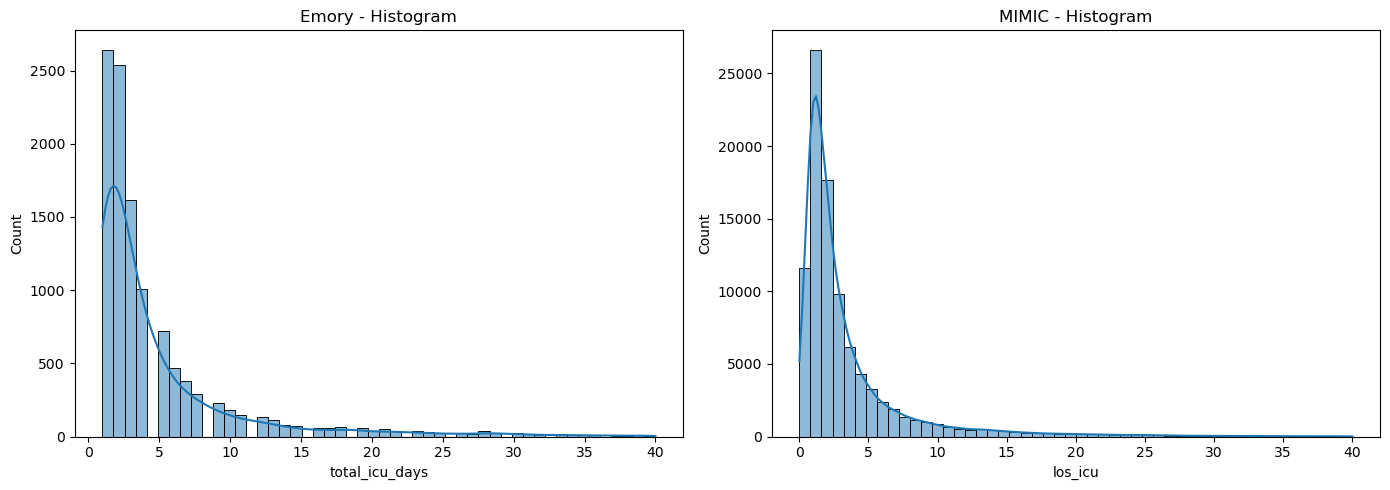

In [21]:
def plot_column_dist(col, source_name, ax, value_range=None):
    if pd.api.types.is_numeric_dtype(col):
        col_to_plot = col.dropna()
        if value_range:
            col_to_plot = col_to_plot[(col_to_plot >= value_range[0]) & (col_to_plot <= value_range[1])]
        sns.histplot(col_to_plot, kde=True, bins=50, ax=ax)
        ax.set_title(f"{source_name} - Histogram")
        ax.set_xlabel(col.name)
    else:
        col.value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f"{source_name} - Bar Chart")
        ax.set_ylabel("Count")
        ax.set_xlabel(col.name)

value_range = (0, 40)  # <- You can adjust this range based on expected values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_column_dist(e_col, "Emory", axes[0], value_range=value_range)
plot_column_dist(m_col, "MIMIC", axes[1], value_range=value_range)
plt.tight_layout()
plt.show()


In [22]:

# -- 3.5 Unique Values (for non-numeric) --
if not pd.api.types.is_numeric_dtype(e_col):
    print(f"\n📋 Emory unique values in '{emory_col}':")
    print(e_col.value_counts(dropna=False))

if not pd.api.types.is_numeric_dtype(m_col):
    print(f"\n📋 MIMIC unique values in '{mimic_col}':")
    print(m_col.value_counts(dropna=False))

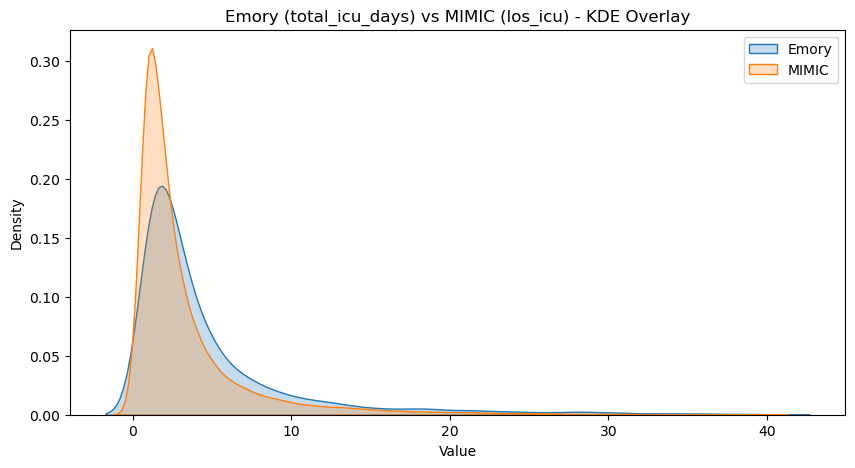

In [23]:
if pd.api.types.is_numeric_dtype(e_col) and pd.api.types.is_numeric_dtype(m_col):
    plt.figure(figsize=(10, 5))

    e_kde = e_col.dropna()
    m_kde = m_col.dropna()

    if value_range:
        e_kde = e_kde[(e_kde >= value_range[0]) & (e_kde <= value_range[1])]
        m_kde = m_kde[(m_kde >= value_range[0]) & (m_kde <= value_range[1])]

    sns.kdeplot(e_kde, label='Emory', fill=True)
    sns.kdeplot(m_kde, label='MIMIC', fill=True)
    plt.title(f"Emory ({emory_col}) vs MIMIC ({mimic_col}) - KDE Overlay")
    plt.xlabel("Value")
    plt.legend()
    plt.show()
else:
    print("\n⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.")
